# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

Estos datasets contienen información de una plataforma de entregas comestibles, estos dataset contienen información sobre los articulos mas vendidos, la frecuencia con la que se venden los productos, infromación complementaria de usuarios que usan o no la plataforma, etc, estos datos nos serviran para hacer el preprocesamiento de datos y el analisis exploratorio.


In [125]:
# importar librerías
import pandas as pd

In [126]:
# leer conjuntos de datos en los DataFrames
instacart = pd.read_csv

In [127]:
# mostrar información del DataFrame
instacart_orders = pd.read_csv("/datasets/instacart_orders.csv", sep=";")

instacart_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [128]:
# mostrar información del DataFrame
instacart_products = pd.read_csv("/datasets/products.csv", sep=";")

instacart_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [129]:
# mostrar información del DataFrame
instacart_aisles = pd.read_csv("/datasets/aisles.csv", sep=";")

instacart_aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [130]:
# mostrar información del DataFrame
instacart_departments = pd.read_csv("/datasets/departments.csv", sep=";")

instacart_departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [131]:
# mostrar información del DataFrame
instacart_order_products = pd.read_csv("/datasets/order_products.csv", sep=";")

instacart_order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

Tenemos información de lo que contienen los Dataset pero la información esta desorganizada y hay que organizarla y segmentarla para que se pueda leer y trabajar de manera eficiente.


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

Se tendra que revisar el dataset para que podamos identificar valores duplicados, y/o valores ausentes, es decir se limpiran las columnas para trabajar con elementos claros. 



## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [132]:
# Revisa si hay pedidos duplicados

print(instacart_orders.drop_duplicates())

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
0        1515936   183418            11          6                 13   
1        1690866   163593             5          5                 12   
2        1454967    39980             4          5                 19   
3        1768857    82516            56          0                 20   
4        3007858   196724             2          4                 12   
...          ...      ...           ...        ...                ...   
478962   3210681     5617             5          1                 14   
478963   3270802   112087             2          3                 13   
478964    885349    82944            16          2                 11   
478965    216274     4391             3          3                  8   
478966   2071924     1730            18          1                 14   

        days_since_prior_order  
0                         30.0  
1                          9.0  
2                       

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

que a simple vista son tipos de datos int 

In [133]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.

pedidos_miercoles_2am = instacart_orders[
    (instacart_orders["order_dow"] == 3) & (instacart_orders["order_hour_of_day"] ==2)
]

print(f"Numero de pedidos:{len(pedidos_miercoles_2am)}")
    
print(pedidos_miercoles_2am.head(10))

Numero de pedidos:121
       order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838    2766110   162084            41          3                  2   
5156    2190225   138285            18          3                  2   
15506    553049    58599            13          3                  2   
18420    382357   120200            19          3                  2   
24691    690242    77357             2          3                  2   
25376   1378085    75705            21          3                  2   
26301   2846262   176827             2          3                  2   
29129    353088    46038             4          3                  2   
30371   1918001   188546            14          3                  2   
31404   1725788   147843            10          3                  2   

       days_since_prior_order  
4838                     16.0  
5156                     11.0  
15506                     7.0  
18420                    11.0  
24691                    

¿Qué sugiere este resultado?

El resultado es que se hicieron 106 compras el dia miercoles a las 2am


In [134]:
# Elimina los pedidos duplicados

instacart_orders = instacart_orders.drop_duplicates()

print(f"Filas después de eliminar duplicados: {len(instacart_orders)}")

Filas después de eliminar duplicados: 478952


In [135]:
# Vuelve a verificar si hay filas duplicadas

print(instacart_orders.duplicated().sum())


0


In [136]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos

instacart_orders["order_id"].duplicated().sum()


0

Describe brevemente tus hallazgos y lo que hiciste con ellos

### `products` data frame

In [137]:
# Verifica si hay filas totalmente duplicadas

print(instacart_products.drop_duplicates())
print(instacart_products.drop_duplicates().sum())


       product_id                                       product_name  \
0               1                         Chocolate Sandwich Cookies   
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               5                          Green Chile Anytime Sauce   
...           ...                                                ...   
49689       49690                      HIGH PERFORMANCE ENERGY DRINK   
49690       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
49691       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR   
49692       49693                             SPRING WATER BODY WASH   
49693       49694                            BURRITO- STEAK & CHEESE   

       aisle_id  department_id  
0            61             19  
1           104             13  
2            94              7  
3  

In [138]:
# Revisa únicamente si hay ID de productos duplicados

instacart_products['product_id'].duplicated().sum()

duplicados = instacart_products[instacart_products['product_id'].duplicated(keep=False)]

print(duplicados)



Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [139]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)

#covertir nombres a mayusculas para mejor comparación
instacart_products['product_name_upper'] = instacart_products['product_name'].str.upper()

#Verificar duplicados en nombres (excluyendo los valores nulos)
duplicados_nombres = instacart_products['product_name_upper'].duplicated().sum()

print(f"Nombres duplicados encontrados: {duplicados_nombres}")

Nombres duplicados encontrados: 1361


In [140]:
# Revisa si hay nombres duplicados de productos no faltantes

productos_con_nombres = instacart_products[instacart_products['product_name'].notna()].copy()

productos_con_nombres['product_name_upper'] = productos_con_nombres['product_name'].str.upper()
duplicados_no_faltantes = productos_con_nombres['product_name_upper'].duplicated().sum()
print(f"Nombres duplicados (excluyendo faltantes): {duplicados_no_faltantes}")


Nombres duplicados (excluyendo faltantes): 104


Describe brevemente tus hallazgos y lo que hiciste con ellos.

se revisaron las filas duplicadas y se encontraron 1361 nombres duplicados 

### `departments` data frame

In [141]:
# Revisa si hay filas totalmente duplicadas

filas_duplicadas = instacart_departments[instacart_departments.duplicated(keep=False)]
print(filas_duplicadas)


Empty DataFrame
Columns: [department_id, department]
Index: []


In [142]:
# Revisa únicamente si hay IDs duplicadas de departamentos

total_filas = len(instacart_departments)
ids_unicos = instacart_departments['department_id'].nunique()
print(f'Total de filas: {total_filas}')
print(f'IDs únicos: {ids_unicos}')
print(f'¿Hay duplicados?: {total_filas != ids_unicos}')


Total de filas: 21
IDs únicos: 21
¿Hay duplicados?: False


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `aisles` data frame

In [143]:
# Revisa si hay filas totalmente duplicadas

filas_duplicadas_aisles = instacart_aisles[instacart_aisles.duplicated(keep=False)]
print(filas_duplicadas_aisles)


Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


In [144]:
# Revisa únicamente si hay IDs duplicadas de pasillos

total_filas_duplicadas_aisles = len(instacart_aisles)
ids_unicos_aisles = instacart_aisles['aisle_id'].nunique()
print(f'Total de filas: {total_filas_duplicadas_aisles}')
print(f'IDs únicos: {ids_unicos_aisles}')
print(f'¿Hay duplicados?: {total_filas_duplicadas_aisles != ids_unicos_aisles}')


Total de filas: 134
IDs únicos: 134
¿Hay duplicados?: False


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se encontraron 134 duplicados en la columna de pasillos

### `order_products` data frame

In [145]:
# Revisa si hay filas totalmente duplicadas

filas_duplicadas_order_products = len(instacart_order_products)
ids_unicos_order_products = instacart_order_products['product_id'].nunique()
print(f'Total de filas: {filas_duplicadas_order_products}')
print(f'IDs únicos: {ids_unicos_order_products}')
print(f'¿Hay duplicados?: {filas_duplicadas_order_products != ids_unicos_order_products}')


Total de filas: 4545007
IDs únicos: 45573
¿Hay duplicados?: True


In [146]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso

duplicados_combinacion = instacart_order_products.duplicated(subset=['order_id', 'product_id']).sum()
print(f'Combinaciones duplicadas de order_id + product_id: {duplicados_combinacion}')



Combinaciones duplicadas de order_id + product_id: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.



## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [147]:
# Encuentra los valores ausentes en la columna 'product_name'

valores_ausentes = instacart_products['product_name'].isnull().sum()
print(f'Valores ausentes en product_name: {valores_ausentes}')

# Ver filas con valores ausentes:

productos_sin_nombre = instacart_products[instacart_products['product_name'].isnull()]
print(productos_sin_nombre.head())

# Verificar el porcentaje:

porcentaje_ausentes = (valores_ausentes / len(instacart_products))*100
print(f'Porcentaje de productos sin nombre: {porcentaje_ausentes: .2f}%')


Valores ausentes en product_name: 1258
     product_id product_name  aisle_id  department_id product_name_upper
37           38          NaN       100             21                NaN
71           72          NaN       100             21                NaN
109         110          NaN       100             21                NaN
296         297          NaN       100             21                NaN
416         417          NaN       100             21                NaN
Porcentaje de productos sin nombre:  2.53%


Describe brevemente cuáles son tus hallazgos.

El numero total de valores ausentes es de: 1258

In [148]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?

productos_sin_nombre = instacart_products[instacart_products['product_name'].isnull()]
print('Pasillos de productos sin nombre:')
print(productos_sin_nombre['aisle_id'].value_counts())


Pasillos de productos sin nombre:
100    1258
Name: aisle_id, dtype: int64


Describe brevemente cuáles son tus hallazgos.

el numero total de valores ausentes en el pasillo 100 es de: 1258

In [149]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?

productos_sin_nombre = instacart_products[instacart_products['product_name'].isnull()]
print('Departamentos de productos sin nombre:')
print(productos_sin_nombre['department_id'].value_counts())


Departamentos de productos sin nombre:
21    1258
Name: department_id, dtype: int64


Describe brevemente cuáles son tus hallazgos.

el departamento 21 tiene un total de 1258 valores ausentes 

In [150]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.

# Filtrar la tabla aisles para encontrar el pasillo con ID 100
pasillo_100 = instacart_aisles[instacart_aisles['aisle_id'] == 100]
print(pasillo_100)

# Filtrar la tabla departmets para encontrar el departamento con ID 21

departamento_21 = instacart_departments[instacart_departments['department_id'] == 21]
print(departamento_21)





    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.

In [151]:
# Completa los nombres de productos ausentes con 'Unknown'

instacart_products['product_name'] = instacart_products['product_name'].fillna('Unknown')

print(instacart_products)



       product_id                                       product_name  \
0               1                         Chocolate Sandwich Cookies   
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               5                          Green Chile Anytime Sauce   
...           ...                                                ...   
49689       49690                      HIGH PERFORMANCE ENERGY DRINK   
49690       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
49691       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR   
49692       49693                             SPRING WATER BODY WASH   
49693       49694                            BURRITO- STEAK & CHEESE   

       aisle_id  department_id  \
0            61             19   
1           104             13   
2            94              7   

Describe brevemente tus hallazgos y lo que hiciste con ellos.

se sustituyeron los valores ausentes por Unknown

### `orders` data frame

In [152]:
# Encuentra los valores ausentes

valores_ausentes = instacart_orders['days_since_prior_order'].isnull().sum()
print(f'Valores ausentes en days_since_prior_order: {valores_ausentes}')

# informacion completa del DataFrame

instacart_orders.info()

# Ver filas que tienen valores ausentes

pedidos_sin_dias = instacart_orders[instacart_orders['days_since_prior_order'].isnull()]
print(pedidos_sin_dias.head())


Valores ausentes en days_since_prior_order: 28817
<class 'pandas.core.frame.DataFrame'>
Int64Index: 478952 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478952 non-null  int64  
 1   user_id                 478952 non-null  int64  
 2   order_number            478952 non-null  int64  
 3   order_dow               478952 non-null  int64  
 4   order_hour_of_day       478952 non-null  int64  
 5   days_since_prior_order  450135 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 25.6 MB
     order_id  user_id  order_number  order_dow  order_hour_of_day  \
28     133707   182261             1          3                 10   
96     787445    25685             1          6                 18   
100    294410   111449             1          0                 19   
103   2869915   123958             1          4                 16   
104   2

In [153]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?

pedidos_sin_dias = instacart_orders[instacart_orders['days_since_prior_order'].isnull()]

#verificar los números de pedido de estos casos

print('Distrubución de order_number en pedidos sin dias:')
print(pedidos_sin_dias['order_number'].value_counts().sort_index())

#Verificar si hay pedidos que NO sean el primer pedido (order_number != 1)

no_primeros_pedidos = pedidos_sin_dias[pedidos_sin_dias['order_number'] != 1]
print(f'\nPedidos sin dias que NO son primeros pedidos: {len(no_primeros_pedidos)}')



Distrubución de order_number en pedidos sin dias:
1    28817
Name: order_number, dtype: int64

Pedidos sin dias que NO son primeros pedidos: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `order_products` data frame

In [154]:
# Encuentra los valores ausentes

valores_ausentes = instacart_order_products['add_to_cart_order'].isnull().sum()
print(f'Valores ausentes en add_to_cart_order: {valores_ausentes}')

# Ver filas con valores ausentes: 

productos_en_carrito = instacart_order_products[instacart_order_products['add_to_cart_order'].isnull()]
print(productos_en_carrito.head())


Valores ausentes en add_to_cart_order: 836
       order_id  product_id  add_to_cart_order  reordered
737     2449164        5068                NaN          0
9926    1968313       43867                NaN          0
14394   2926893       11688                NaN          0
16418   1717990        4142                NaN          0
30114   1959075       42828                NaN          1


In [155]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?

min_valor = instacart_order_products['add_to_cart_order'].min()
max_valor = instacart_order_products['add_to_cart_order'].max()

print(f'Valor mínimo en add_to_cart_order: {min_valor}')
print(f'Valor máximo en add_to_cart_order: {max_valor}')



Valor mínimo en add_to_cart_order: 1.0
Valor máximo en add_to_cart_order: 64.0


Describe brevemente cuáles son tus hallazgos.

el total de filas con valores ausentes es de: 836

In [156]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'

pedidos_con_valores_ausentes = instacart_order_products[
    instacart_order_products['add_to_cart_order'].isnull()
    ]['order_id'].unique()

print(f'Numero de pedidos únicos con valores ausentes: {len(pedidos_con_valores_ausentes)}')
print(f'Primeros 10 IDs de pedidos: {pedidos_con_valores_ausentes[:10]}')


Numero de pedidos únicos con valores ausentes: 70
Primeros 10 IDs de pedidos: [2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093]


In [157]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

pedidos_con_ausentes = instacart_order_products[
    instacart_order_products['add_to_cart_order'].isnull()
]['order_id'].unique()

conteo_productos = instacart_order_products[
    instacart_order_products['order_id'].isin(pedidos_con_ausentes)
].groupby('order_id').size()

print(f'Número total de productos por pedido (con valores ausentes):')
print(f'Mínimo: {conteo_productos.min()}')
print(f'Máximo: {conteo_productos.max()}')
print(f'Promedio: {conteo_productos.mean():.2}')

pedidos_mas_64 = (conteo_productos > 64).sum()
print(f'Pedidos con más de 64 productos: {pedidos_mas_64} de {len(conteo_productos)}')



Número total de productos por pedido (con valores ausentes):
Mínimo: 65
Máximo: 127
Promedio: 7.6e+01
Pedidos con más de 64 productos: 70 de 70


Describe brevemente cuáles son tus hallazgos.

In [158]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.

instacart_order_products['add_to_cart_order'] = instacart_order_products['add_to_cart_order'].fillna(999).astype(int)

print("Verificación del remplazo:")
print(f"Valores ausentes después del reemplazo: {instacart_order_products['add_to_cart_order'].isnull().sum()}")
print(f"Valores con 999: {(instacart_order_products['add_to_cart_order'] == 999).sum()}")
print(f"Tipo de datos: {instacart_order_products['add_to_cart_order'].dtype}")



Verificación del remplazo:
Valores ausentes después del reemplazo: 0
Valores con 999: 836
Tipo de datos: int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.

se reemplazaron los valores ausentes en la columna add to cart y se convirtieron en tipo entero

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

Se ajustaron los datos para poder trabajar con ellos y asi evitar errores, principalmente se encontraron errores en el tipo de datos, los valores ausentes en las diferentes filas y columnas. 


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [159]:
print("=== Verificación de order_hour_of_day ===")
print(f"Valor mínimo: {instacart_orders['order_hour_of_day'].min()}")
print(f"Valor máximo: {instacart_orders['order_hour_of_day'].max()}")
print(f"¿Está en rango 0-23?: {instacart_orders['order_hour_of_day'].min() >= 0 and instacart_orders['order_hour_of_day'].max() <= 23}")

print("\n=== Verificación de order_dow ===")
print(f"Valor mínimo: {instacart_orders['order_dow'].min()}")
print(f"Valor mínimo: {instacart_orders['order_dow'].max()}")
print(f"¿Está en rango 0-6?: {instacart_orders['order_dow'].min() >= 0 and instacart_orders['order_dow'].max() <=6}")


=== Verificación de order_hour_of_day ===
Valor mínimo: 0
Valor máximo: 23
¿Está en rango 0-23?: True

=== Verificación de order_dow ===
Valor mínimo: 0
Valor mínimo: 6
¿Está en rango 0-6?: True


In [160]:
print(f"\nValores únicos en order_hour_of_day: {sorted(instacart_orders['order_hour_of_day'].unique())}")
print(f"Valores únicos en order_dow: {sorted(instacart_orders['order_dow'].unique())}")


Valores únicos en order_hour_of_day: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Valores únicos en order_dow: [0, 1, 2, 3, 4, 5, 6]


Escribe aquí tus conclusiones

los datos si se encuentran en un rango de 24 horas y 7 dias de la semana

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

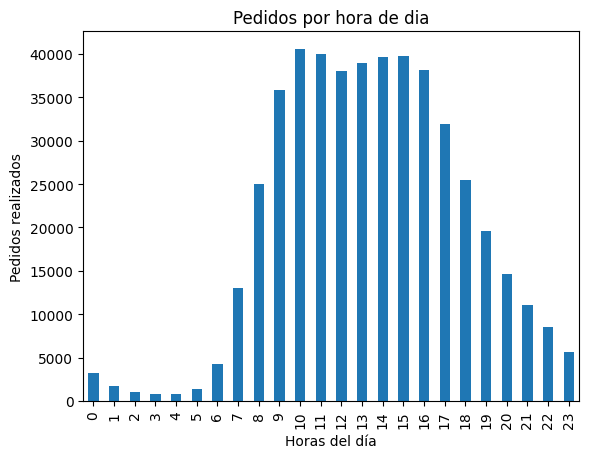

In [161]:
import matplotlib.pyplot as plt

pedidos_por_hora = instacart_orders['order_hour_of_day'].value_counts().sort_index()
pedidos_por_hora.plot(kind='bar')
plt.title('Pedidos por hora de dia') 
plt.xlabel('Horas del día')  
plt.ylabel('Pedidos realizados')  
plt.show()



Escribe aquí tus conclusiones

### [A3] ¿Qué día de la semana compran víveres las personas?

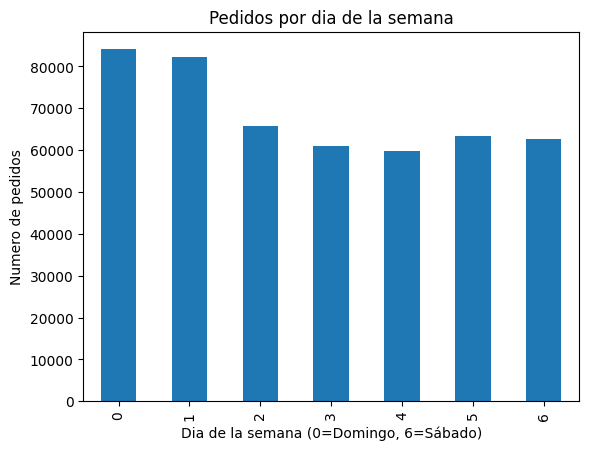

In [162]:
import matplotlib.pyplot as plt

pedidos_por_dia = instacart_orders['order_dow'].value_counts().sort_index()

pedidos_por_dia.plot(kind='bar',
                    title='Pedidos por dia de la semana',
                    xlabel='Dia de la semana (0=Domingo, 6=Sábado)',
                    ylabel='Numero de pedidos'
                    )
plt.show()

Escribe aquí tus conclusiones

los dias domingos se realizan más compras que en resto de la semana 


[A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

=== Estadísticas de días entre pedidos ===
Valor mínimo: 0.0
Valor máximo: 30.0
Promedio: 11.10
Mediana: 7.0


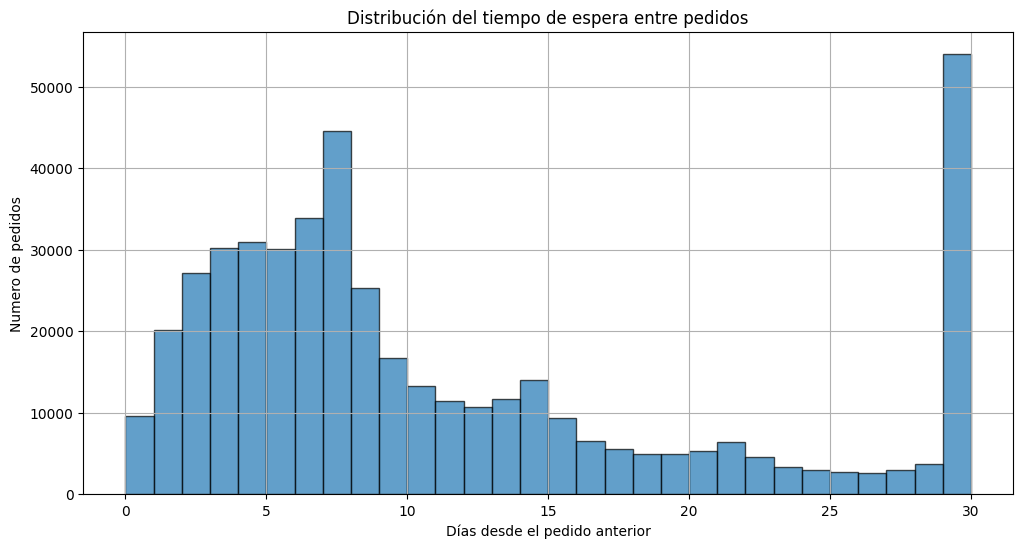

In [163]:
print("=== Estadísticas de días entre pedidos ===")
print(f"Valor mínimo: {instacart_orders['days_since_prior_order'].min()}")
print(f"Valor máximo: {instacart_orders['days_since_prior_order'].max()}")
print(f"Promedio: {instacart_orders['days_since_prior_order'].mean():.2f}")
print(f"Mediana: {instacart_orders['days_since_prior_order'].median()}")

import matplotlib.pyplot as plt

dias_validos = instacart_orders['days_since_prior_order'].dropna()

plt.figure(figsize=(12, 6))

plt.hist(dias_validos, bins=30, edgecolor='black', alpha=0.7)

plt.title('Distribución del tiempo de espera entre pedidos')
plt.xlabel('Días desde el pedido anterior')
plt.ylabel('Numero de pedidos')
plt.grid(True)

plt.show()


Escribe aquí tus conclusiones

la mayoria de clientes tarda un tiempo aproximado de 10 dias para volver a realizar un nuevo pedido 

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [ ]:
# order_dow = 3 Miercoles
# order_dow = 6 Sábado
# order_hour_of_day  Hora del día (0-23)

In [164]:
# Filtrar pedidos de Miércoles (order_dow = 3)
pedidos_miercoles = instacart_orders[instacart_orders['order_dow'] == 3]

# Filtrar pedidos de Sábado (order_dow = 6)
pedidos_sabado = instacart_orders[instacart_orders['order_dow'] == 6]


In [165]:
# Contar pedidos por hora para Miércoles
miercoles_por_hora = pedidos_miercoles['order_hour_of_day'].value_counts().sort_index()

# Contar pedidos por hora para Sábado
sabado_por_hora = pedidos_sabado['order_hour_of_day'].value_counts().sort_index()


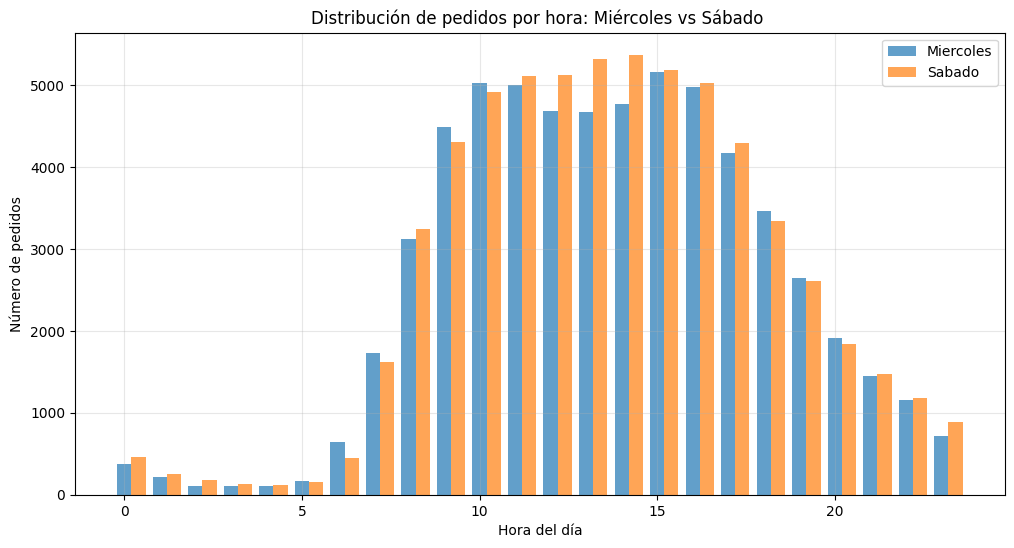

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(miercoles_por_hora.index, miercoles_por_hora.values,
       alpha=0.7, label='Miercoles', width=0.4)
plt.bar(sabado_por_hora.index + 0.4, sabado_por_hora.values,
       alpha=0.7, label='Sabado', width=0.4)

plt.title('Distribución de pedidos por hora: Miércoles vs Sábado ')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Escribe aquí tus conclusiones

a las 3 de la tarde es una buena hora para hacer compras 

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [167]:
# Contar cuántos pedidos hizo cada cliente 

pedidos_por_cliente = instacart_orders['user_id'].value_counts()
print("Primeros 10 clientes y sus pedidos:")
print(pedidos_por_cliente.head(10))

Primeros 10 clientes y sus pedidos:
149605    28
193164    26
78375     25
148162    24
66664     24
134511    24
54259     23
183981    23
106869    23
139660    23
Name: user_id, dtype: int64


Distribución de pedidos:
1     55357
2     36508
3     21547
4     13498
5      8777
6      6012
7      4240
8      3019
9      2152
10     1645
Name: user_id, dtype: int64


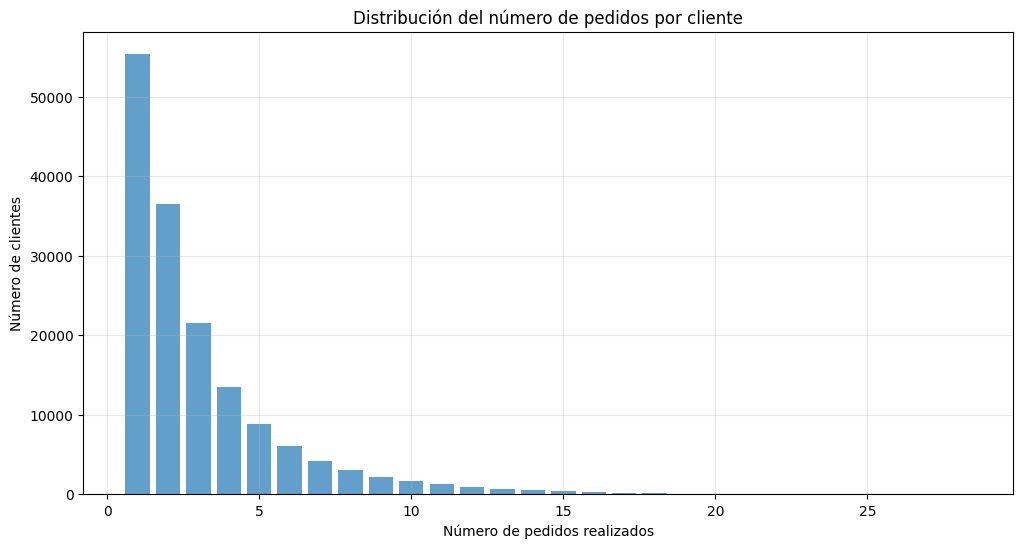

In [168]:
# Contar cuántos clientes hicieron 1 pedido, 2 pedidos, etc

distribucion_pedidos = pedidos_por_cliente.value_counts().sort_index()
print('Distribución de pedidos:')
print(distribucion_pedidos.head(10))

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(distribucion_pedidos.index, distribucion_pedidos.values, alpha=0.7)
plt.title('Distribución del número de pedidos por cliente')
plt.xlabel("Número de pedidos realizados")
plt.ylabel("Número de clientes")
plt.grid(True, alpha=0.3)
plt.show()


Escribe aquí tus conclusiones

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [169]:
# Contar cuántas veces se pidió cada producto

productos_mas_pedidos = instacart_order_products['product_id'].value_counts()
print("Los 10 productos más pedidos (solo IDs):")
print(productos_mas_pedidos.head(10))


Los 10 productos más pedidos (solo IDs):
24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
47766    24689
47626    21495
16797    20018
26209    19690
27845    19600
Name: product_id, dtype: int64


In [170]:
# Obtener los 20 productos más pedidos 

top_20_productos = productos_mas_pedidos.head(20)
print("Top 20 productos más pedidos:")
print(top_20_productos)


Top 20 productos más pedidos:
24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
47766    24689
47626    21495
16797    20018
26209    19690
27845    19600
27966    19197
22935    15898
24964    15292
45007    14584
39275    13879
49683    13675
28204    12544
5876     12232
8277     11993
40706    11781
Name: product_id, dtype: int64


In [96]:
# Convertir a DataFrame para poder hacer merge

top_20_df = top_20_productos.reset_index()
top_20_df.columns = ['product_id', 'cantidad_pedidos']

# Hacer merge con la tabla de productos para obtener los nombres

resultado = top_20_df.merge(instacart_products[['product_id', 'product_name']], on='product_id', how='left')
print("Top 20 productos con nombres:")
print(resultado)


Top 20 productos con nombres:
    product_id  cantidad_pedidos              product_name
0        24852             66050                    Banana
1        13176             53297    Bag of Organic Bananas
2        21137             37039      Organic Strawberries
3        21903             33971      Organic Baby Spinach
4        47209             29773      Organic Hass Avocado
5        47766             24689           Organic Avocado
6        47626             21495               Large Lemon
7        16797             20018              Strawberries
8        26209             19690                     Limes
9        27845             19600        Organic Whole Milk
10       27966             19197       Organic Raspberries
11       22935             15898      Organic Yellow Onion
12       24964             15292            Organic Garlic
13       45007             14584          Organic Zucchini
14       39275             13879       Organic Blueberries
15       49683            

Escribe aquí tus conclusiones

frutas y verduras son los productos con mayor demanda 

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [171]:
# Contar cuántos artículos tiene cada pedido

articulos_por_pedido = instacart_order_products['order_id'].value_counts()
print("Primeros 10 pedidos y cantidad de artículos:")
print(articulos_por_pedido.head(10))

# Obtener estadística descritivas 
print("Estadísticas de artículos por pedido:")
print(articulos_por_pedido.describe())
print(f"\nPromedio de artículos por pedido: {articulos_por_pedido.mean():.2f}")
print(f"Medida de artículos por pedido: {articulos_por_pedido.median():.2f}")


Primeros 10 pedidos y cantidad de artículos:
61355      127
3308010    115
2136777    108
171934     104
1959075     98
102236      95
1730767     95
1800005     92
2926893     92
1386261     91
Name: order_id, dtype: int64
Estadísticas de artículos por pedido:
count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: order_id, dtype: float64

Promedio de artículos por pedido: 10.10
Medida de artículos por pedido: 8.00


In [172]:
# Crear distribución: cuántos pedidos tienen 1 articulo, 2 articulos. etc

distribucion_articulos = articulos_por_pedido.value_counts().sort_index()
print("Distribución de artículos por pedido:")
print(distribucion_articulos.head(15))


Distribución de artículos por pedido:
1     21847
2     26292
3     29046
4     31054
5     31923
6     31698
7     30822
8     28539
9     25742
10    23248
11    20406
12    18539
13    16497
14    14472
15    12696
Name: order_id, dtype: int64


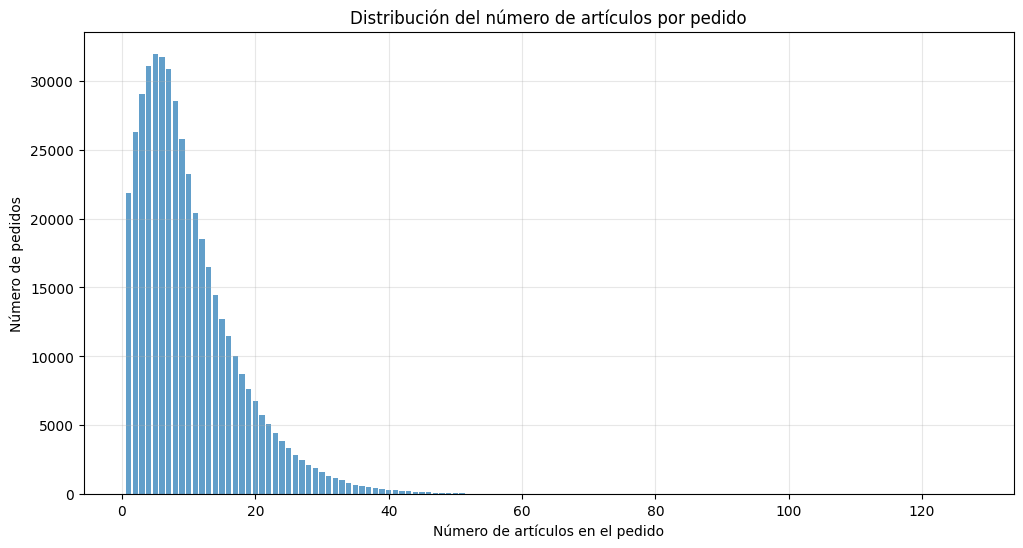

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(distribucion_articulos.index, distribucion_articulos.values, alpha=0.7)
plt.title('Distribución del número de artículos por pedido')
plt.xlabel('Número de artículos en el pedido')
plt.ylabel('Número de pedidos')
plt.grid(True, alpha=0.3)
plt.show()


Escribe aquí tus conclusiones

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [174]:
# Filtrar solo los productos que fueron reordenados (reordered = 1)

productos_reordenados = instacart_order_products[instacart_order_products['reordered'] == 1]
print(f"Total de productos reordenados: {len(productos_reordenados)}")

Total de productos reordenados: 2683838


In [175]:
# Contar cuántas veces se reordenó cada producto 

productos_mas_reordenados = productos_reordenados['product_id'].value_counts()
print("Los 10 productos más reordenados (solo IDs):")
print(productos_mas_reordenados.head(10))


Los 10 productos más reordenados (solo IDs):
24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
47766    18743
27845    16251
47626    15044
27966    14748
16797    13945
Name: product_id, dtype: int64


In [176]:
# Obtener los 20 productos más reordenados 
top_20_reordenados = productos_mas_reordenados.head(20)
print("Top 20 productos más reordenados:")
print(top_20_reordenados)

Top 20 productos más reordenados:
24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
47766    18743
27845    16251
47626    15044
27966    14748
16797    13945
26209    13327
22935    11145
24964    10411
45007    10076
49683     9538
28204     8989
8277      8836
39275     8799
5876      8412
49235     8389
Name: product_id, dtype: int64


In [177]:
# Convertir a DataFrame u hacer merge con nombres 

top_20_reordenados_df = top_20_reordenados.reset_index()
top_20_reordenados_df.columns = ['product_id', 'veces_reordenado']

resultado_reordenados = top_20_reordenados_df.merge(instacart_products[['product_id', 'product_name']], on='product_id', how='left')

print("Top 20 productos más reordenados con nombres:")
print(resultado_reordenados)

Top 20 productos más reordenados con nombres:
    product_id  veces_reordenado              product_name
0        24852             55763                    Banana
1        13176             44450    Bag of Organic Bananas
2        21137             28639      Organic Strawberries
3        21903             26233      Organic Baby Spinach
4        47209             23629      Organic Hass Avocado
5        47766             18743           Organic Avocado
6        27845             16251        Organic Whole Milk
7        47626             15044               Large Lemon
8        27966             14748       Organic Raspberries
9        16797             13945              Strawberries
10       26209             13327                     Limes
11       22935             11145      Organic Yellow Onion
12       24964             10411            Organic Garlic
13       45007             10076          Organic Zucchini
14       49683              9538            Cucumber Kirby
15       2

Escribe aquí tus conclusiones

este procesamiento de datos nos da mejor visibilidad de lo que la empresa vende con mayor frecuencia 

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [178]:
# Contar cuántas veces se pidió cada producto en total

total_pedidos_por_producto = instacart_order_products['product_id'].value_counts()
print("Total de pedidos por producto (primeros 10):")
print(total_pedidos_por_producto.head(10))

# Filtrar solo productos reordenados y contarlos

productos_reordenados = instacart_order_products[instacart_order_products['reordered'] == 1]
reordenes_por_producto = productos_reordenados['product_id'].value_counts()
print("Reórdenes por producto (primeros 10):")
print(reordenes_por_producto.head(10))


Total de pedidos por producto (primeros 10):
24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
47766    24689
47626    21495
16797    20018
26209    19690
27845    19600
Name: product_id, dtype: int64
Reórdenes por producto (primeros 10):
24852    55763
13176    44450
21137    28639
21903    26233
47209    23629
47766    18743
27845    16251
47626    15044
27966    14748
16797    13945
Name: product_id, dtype: int64


In [179]:
# Crear DataFrame con ambos conteos

import pandas as pd
 
# Convertir a DataFrame
df_total = total_pedidos_por_producto.reset_index()
df_total.columns = ['product_id', 'total_pedidos']

df_reordenes = reordenes_por_producto.reset_index()
df_reordenes.columns = ['product_id', 'reordenes']

# Hacer merge
tasa_repeticion = df_total.merge(df_reordenes, on='product_id', how='left')
# Llenar valores NaN con 0 (productos que nunca se reordenaron)
tasa_repeticion['reordenes'] = tasa_repeticion['reordenes'].fillna(0)

# Calcular la tasa de repetición
tasa_repeticion['tasa_repeticion'] = tasa_repeticion['reordenes'] / tasa_repeticion['total_pedidos']

print("Tasa de repetición por producto:")
print(tasa_repeticion.head(10))


Tasa de repetición por producto:
   product_id  total_pedidos  reordenes  tasa_repeticion
0       24852          66050    55763.0         0.844254
1       13176          53297    44450.0         0.834006
2       21137          37039    28639.0         0.773212
3       21903          33971    26233.0         0.772217
4       47209          29773    23629.0         0.793639
5       47766          24689    18743.0         0.759164
6       47626          21495    15044.0         0.699884
7       16797          20018    13945.0         0.696623
8       26209          19690    13327.0         0.676841
9       27845          19600    16251.0         0.829133


In [180]:
# Agregar nombres de productos

resultado_final = tasa_repeticion.merge(instacart_products[['product_id', 'product_name']], on='product_id', how='left')

# Ordenar por tasa de repetición más alta
resultado_final = resultado_final.sort_values('tasa_repeticion', ascending=False)

print("Top 20 productos con mayor tasa de repetición:")
print(resultado_final[['product_name', 'total_pedidos', 'reordenes', 'tasa_repeticion']].head(20))

Top 20 productos con mayor tasa de repetición:
                                            product_name  total_pedidos  \
38106                   Fat Free American Cheese Singles              2   
39014                                 San Ignacio Coffee              2   
39021                       Charcoal Briquettes Mesquite              2   
39022                    Instant Rolled Oats Whole Grain              2   
39025                                Nasal Allergy Spray              2   
39029             Whitening Toothpaste with Tea Tree Oil              2   
39032                                            Unknown              2   
39040                            Fruit Punch Fruit Drink              2   
39050                Bonito Del Norte En Aceita De Oliva              2   
39071                     24 Hr 20mg Acid Reducer Tablet              2   
39121                   Sorta Sweet Straight Up Iced Tea              2   
39146                         Astragalus Supreme Extr

Escribe aquí tus conclusiones

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [181]:
# Unir order_products con orders para obtener user_id

datos_completos = instacart_order_products.merge(instacart_orders[['order_id', 'user_id']], on='order_id', how='left')
print("Datos combinados:")
print(datos_completos.head())

Datos combinados:
   order_id  product_id  add_to_cart_order  reordered  user_id
0   2141543       11440                 17          0    58454
1    567889        1560                  1          1   129474
2   2261212       26683                  1          1    47476
3    491251        8670                 35          1   134505
4   2571142        1940                  5          1   155995


In [182]:
# Para cada usuario, contar:
# 1. Total de productos pedidos
# 2. Total de productos reordenados

resumen_usuarios = datos_completos.groupby('user_id').agg({'product_id': 'count', 'reordered': 'sum'}).reset_index()

resumen_usuarios.columns = ['user_id', 'total_productos', 'productos_reordenados']
print("Resumen por usuario:")
print(resumen_usuarios.head())

# Calcular la tasa de repetición para cada usuario
resumen_usuarios['tasa_repeticion_usuario'] = (resumen_usuarios['productos_reordenados'] / resumen_usuarios['total_productos'])
print("Tasa de repetición por usuario:")
print(resumen_usuarios.head(10))



Resumen por usuario:
   user_id  total_productos  productos_reordenados
0        2               26                      1
1        4                2                      0
2        5               12                      8
3        6                4                      0
4        7               14                     13
Tasa de repetición por usuario:
   user_id  total_productos  productos_reordenados  tasa_repeticion_usuario
0        2               26                      1                 0.038462
1        4                2                      0                 0.000000
2        5               12                      8                 0.666667
3        6                4                      0                 0.000000
4        7               14                     13                 0.928571
5       11               15                      3                 0.200000
6       12               12                      3                 0.250000
7       13               23      

Escribe aquí tus conclusiones

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [183]:
# Filtrar productos que fueron agregados primero al carrito

productos_primeros = instacart_order_products[
    instacart_order_products['add_to_cart_order'] == 1]
print(f"Total de productos agregados primero: {len(productos_primeros)}")
print("Primeros 5 registros:")
print(productos_primeros.head())

Total de productos agregados primero: 450046
Primeros 5 registros:
    order_id  product_id  add_to_cart_order  reordered
1     567889        1560                  1          1
2    2261212       26683                  1          1
14   1961225       37553                  1          1
16    639939       10017                  1          1
23    750040        8518                  1          0


In [184]:
# Contar cuántas veces cada producto fue agregado primero

productos_primeros_conteo = productos_primeros['product_id'].value_counts()
print("Los 10 productos más agregados primero (solo IDs):")
print(productos_primeros_conteo.head(10))


Los 10 productos más agregados primero (solo IDs):
24852    15562
13176    11026
27845     4363
21137     3946
47209     3390
21903     3336
47766     3044
19660     2336
16797     2308
27966     2024
Name: product_id, dtype: int64


In [185]:
# Obtener los 20 productos más agregados primero

top_20_primeros = productos_primeros_conteo.head(20)

# Convertir a DataFrame y hacer merge con nombres

top_20_primeros_df = top_20_primeros.reset_index()
top_20_primeros_df.columns = ['product_id', 'veces_primero']

# Agregar nombres de productos

resultado_primeros = top_20_primeros_df.merge(
    instacart_products[['product_id', 'product_name']],on='product_id', how='left')

print("Top 20 productos más agregados primero al carrito:")
print(resultado_primeros[['product_id', 'product_name', 'veces_primero']])

Top 20 productos más agregados primero al carrito:
    product_id                 product_name  veces_primero
0        24852                       Banana          15562
1        13176       Bag of Organic Bananas          11026
2        27845           Organic Whole Milk           4363
3        21137         Organic Strawberries           3946
4        47209         Organic Hass Avocado           3390
5        21903         Organic Baby Spinach           3336
6        47766              Organic Avocado           3044
7        19660                 Spring Water           2336
8        16797                 Strawberries           2308
9        27966          Organic Raspberries           2024
10       44632   Sparkling Water Grapefruit           1914
11       49235          Organic Half & Half           1797
12       47626                  Large Lemon           1737
13         196                         Soda           1733
14       38689     Organic Reduced Fat Milk           1397
15   

Escribe aquí tus conclusiones

### Conclusion general del proyecto:

In [ ]:
Para la empresa Instacart, es de mucha ayuda este procesamiento de información, ya que da una mejor visibilidad de cuales son los productos mas vendidos, que cantidad de productos se venden en un solo pedido, con que frecuencia
se vende cada producto y asi mapear los productos estrella, esta información tambien puede ayudar al equipo de marketing para insentivar ventas o crear campañas, con datos reales que se registraron en la plataforma. 


